<a href="https://colab.research.google.com/github/erzqn412/eeigm2/blob/main/EEIGM_ImageProcessing_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EEIGM 2025**
# Procesado de imagen: TEST FINAL

Profesor: Christian Mata

**Instrucciones**
Crea tu ejercicio usando un gitHub y GoogleColab y envíalo a: christian.mata@upc.edu

(puedes usar tus apuntes de clase)

Tiempo estimado: 1h

## 1. Carga y visualiza la imagen ‘acero’ (usando Google Drive o cargando manualmente la imagen) usando la librería skimage. Informa del tamaño de la imagen, del tipo de imagen y del rango de los niveles de gris de los píxeles.

*(0,5 puntos)*

In [5]:
from google.colab import files # load skimage libraries
import io
uploaded = files.upload()

Saving acero.png to acero (1).png


In [16]:
import skimage as sk # load skimage libraries
from skimage import io
I = sk.io.imread('acero.png') # read image using imread function

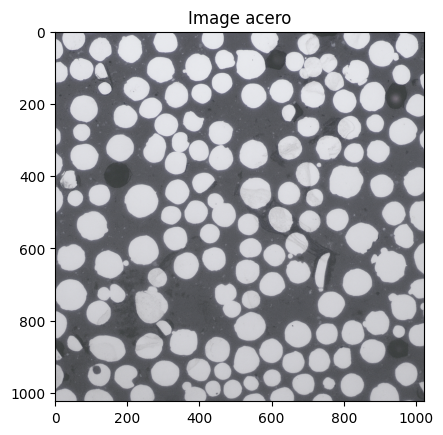

Image size: (1024, 1024, 3)
Image type: uint8
Pixel value range: [46, 253]


In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(I, cmap='gray')
plt.title('Image acero')
plt.show()

print(f"Image size: {I.shape}")
print(f"Image type: {I.dtype}")
print(f"Pixel value range: [{np.min(I)}, {np.max(I)}]")

## 2. Representa el histograma de la imagen. Explica los picos del histograma en función de las regiones de la imagen.

*(0,5 puntos)*

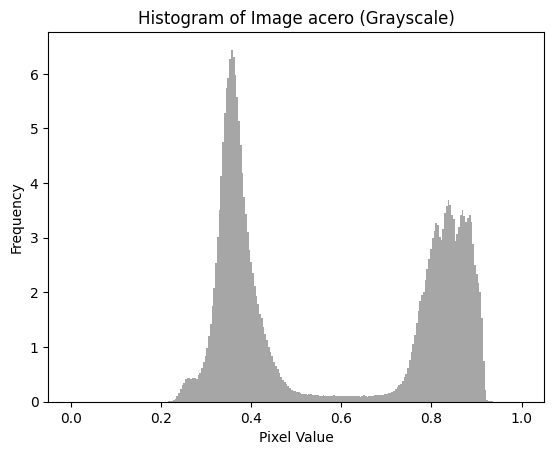

In [19]:
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
import numpy as np

# Convert the image to grayscale
I_gray = rgb2gray(I)

# Flatten the grayscale image to get a 1D array of pixel values
v = I_gray.reshape(I_gray.shape[0]*I_gray.shape[1],1)

# histogram
plt.hist(v, bins=256, range=[0, 1], density=True, color='gray', alpha=0.7)
plt.title('Histogram of Image acero (Grayscale)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

Descripción del resultado obtenido:

## 3. Aplica ruido a la imagen y utiliza la función adecuada para eliminar dicho ruido. Muestra un plot de tres imágenes (imagen original, imagen con ruído e imagen filtrada sin ruido).

*(1 punto)*

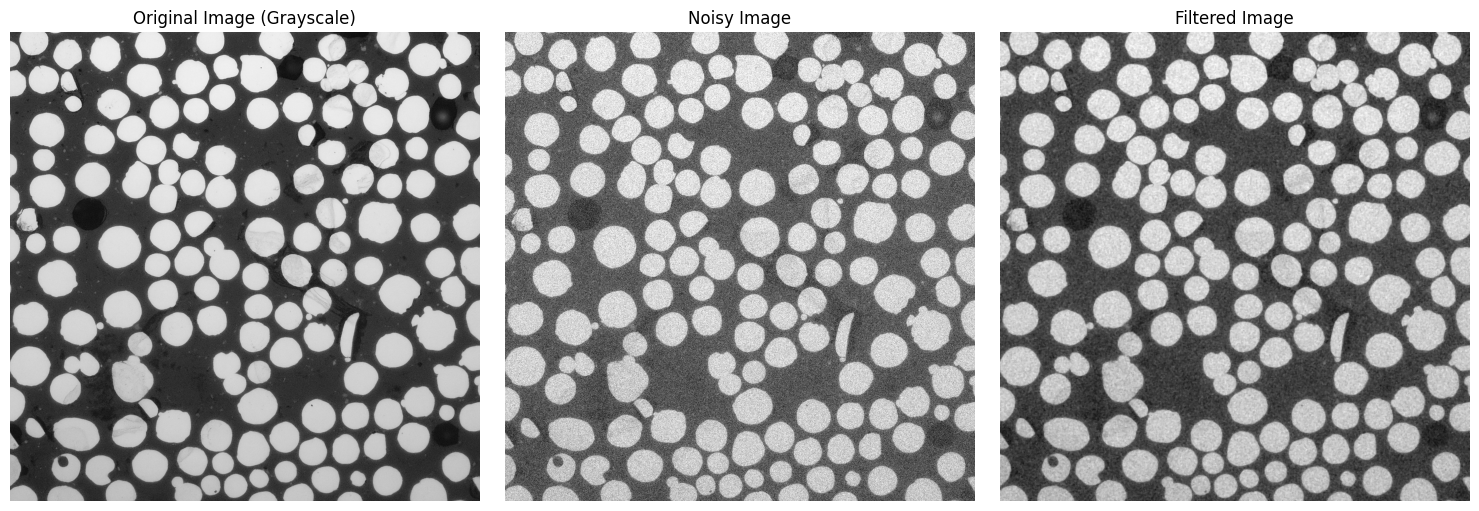

In [25]:
from skimage.util import random_noise
from skimage.filters import gaussian
import matplotlib.pyplot as plt
from skimage.morphology import disk
from skimage.filters import median
from skimage import data
from skimage import img_as_ubyte

noisy_image = random_noise(I_gray, mode='gaussian', var=0.01)

img = img_as_ubyte(noisy_image)
sel5 = disk(2) # structuring element disk radius 5 pixels
filtered_image = median(img, sel5)



# Display the original, noisy, and filtered images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes.ravel()

ax[0].imshow(I_gray, cmap='gray')
ax[0].set_title("Original Image (Grayscale)")
ax[0].axis('off')

ax[1].imshow(noisy_image, cmap='gray')
ax[1].set_title("Noisy Image")
ax[1].axis('off')

ax[2].imshow(filtered_image, cmap='gray')
ax[2].set_title("Filtered Image")
ax[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Segmenta la imagen utilizando un algoritmo de agrupamiento k-means con k = 2 y representa el resultado.
(* Recuerda usar la imagen resultante del apartado anterior, sin ruido)

*(1 punto)*

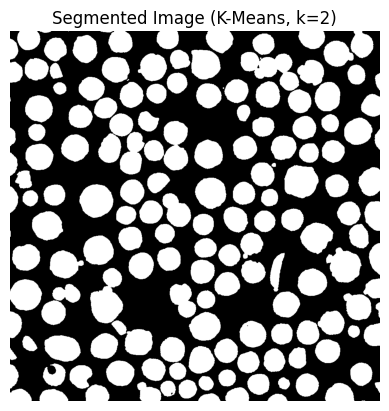

In [34]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Reshape the filtered image to be a 2D array of pixels and their intensity
pixel_values = filtered_image.reshape((-1, 1))

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(pixel_values)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Reshape the labels back into an image
segmented_image = labels.reshape(filtered_image.shape)

# Display the segmented image
plt.imshow(segmented_image, cmap='gray')
plt.title('Segmented Image (K-Means, k=2)')
plt.axis('off')
plt.show()

## 5. Etiqueta los objetos encontrados en la imagen. Genera una figura con la imagen original y la imagen etiquetada.

*(1 punto)*


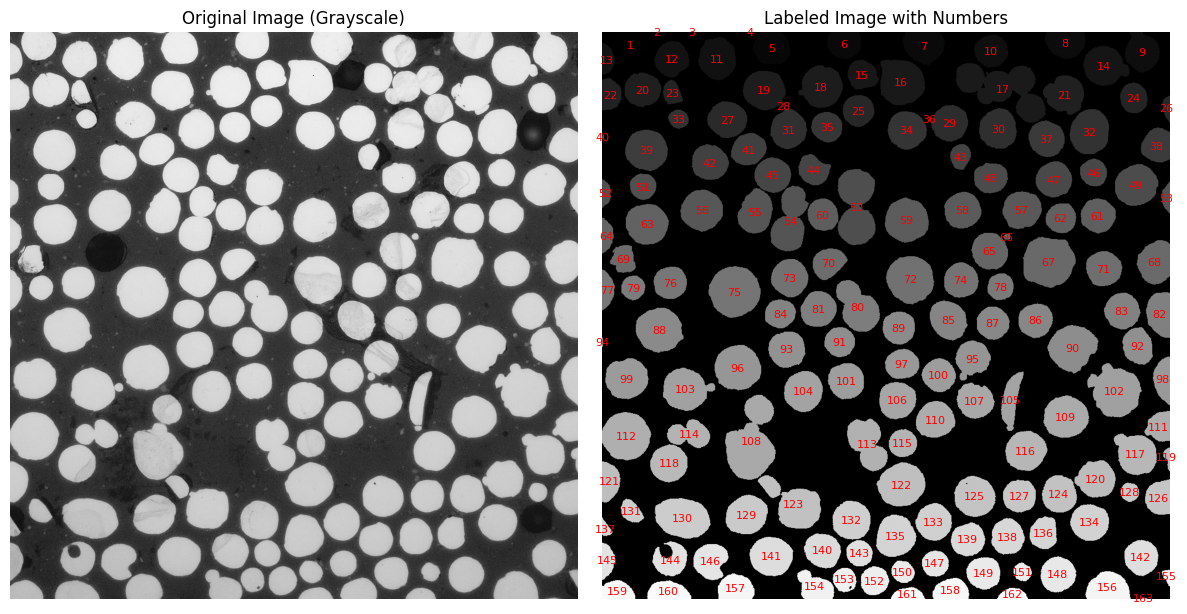

In [37]:
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Label the connected regions in the segmented image
labeled_image = label(segmented_image)

# Display the original and labeled images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes.ravel()

# Display original image
ax[0].imshow(I_gray, cmap='gray')
ax[0].set_title("Original Image (Grayscale)")
ax[0].axis('off')

# Display labeled image with numbers
ax[1].imshow(labeled_image, cmap='gray') # Use gray colormap for the background
ax[1].set_title("Labeled Image with Numbers")
ax[1].axis('off')

# Get region properties
regions = regionprops(labeled_image)

# Add text annotations for each region
for region in regions:
    if region.label == 0: # Skip the background
        continue
    # Get the centroid of the region
    y0, x0 = region.centroid
    ax[1].text(x0, y0, str(region.label), color='red', fontsize=8, ha='center', va='center')

plt.tight_layout()
plt.show()

In [33]:
import numpy as np

# Count the number of unique labels (regions), excluding the background (label 0)
num_regions = len(np.unique(labeled_image)) - 1

print(f"Number of regions in the image: {num_regions}")

Number of regions in the image: 163


Descripción del resultado:
**¿Cuántas regiones hay en la imagen?**

## 6. Extrae característica de cada región: el área, la longitud del eje mayor y la orientación de cada región. Informa de los valores promedio de las características extraídas. Representa un diagrama de dispersión (scatterplot) del área frente a la longitud del eje mayor.

*(1,5 puntos)*

Average Area: 3013.72
Average Major Axis Length: 67.09
Average Orientation: 0.09


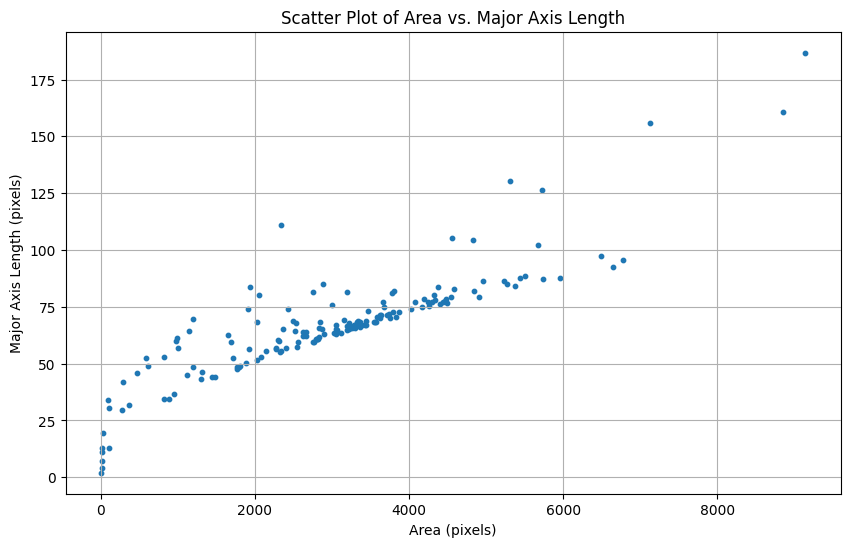

In [38]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt

# Get region properties from the labeled image
regions = regionprops(labeled_image)

# Initialize lists to store the extracted characteristics
areas = []
major_axis_lengths = []
orientations = []

# Extract characteristics for each region (excluding the background)
for region in regions:
    if region.label == 0: # Skip the background
        continue
    areas.append(region.area)
    major_axis_lengths.append(region.major_axis_length)
    orientations.append(region.orientation)

# Calculate and report the average values
average_area = np.mean(areas)
average_major_axis_length = np.mean(major_axis_lengths)
average_orientation = np.mean(orientations)

print(f"Average Area: {average_area:.2f}")
print(f"Average Major Axis Length: {average_major_axis_length:.2f}")
print(f"Average Orientation: {average_orientation:.2f}")

# Create a scatter plot of Area vs. Major Axis Length
plt.figure(figsize=(10, 6))
plt.scatter(areas, major_axis_lengths, s=10) # s is the marker size
plt.title('Scatter Plot of Area vs. Major Axis Length')
plt.xlabel('Area (pixels)')
plt.ylabel('Major Axis Length (pixels)')
plt.grid(True)
plt.show()

## 7. Usando las regiones etiquetadas de la imagen, ¿cómo puedes filtrar las regiones para encontrar aquellas con un área mayor de 4000 píxeles? Indica cuántas regiones de ese tipo hay.
*(1,5 puntos)*

In [39]:
# Filter regions with an area greater than 4000 pixels
large_regions = [region for region in regions if region.area > 4000]

# Count the number of large regions
num_large_regions = len(large_regions)

print(f"Number of regions with area greater than 4000 pixels: {num_large_regions}")

Number of regions with area greater than 4000 pixels: 38


## 8. Ahora usaremos el algoritmo Otsu utilizando la imagen sin ruído. Muestra los resultados e indica el número de regiones detectadas.

*(2 puntos)*

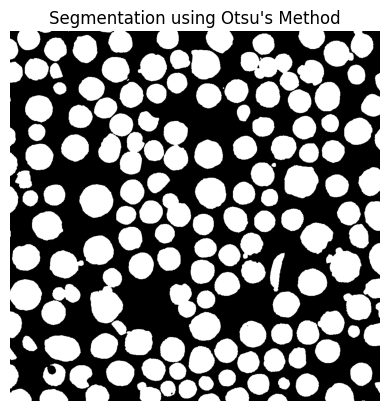

Number of regions detected using Otsu's method: 163


In [40]:
from skimage.filters import threshold_otsu
from skimage.measure import label
import matplotlib.pyplot as plt
import numpy as np

# Apply Otsu's thresholding to the noise-free grayscale image (filtered_image)
otsu_threshold = threshold_otsu(filtered_image)
binary_image_otsu = filtered_image > otsu_threshold

# Label the connected regions in the binary image
labeled_image_otsu = label(binary_image_otsu)

# Display the binary image obtained using Otsu's method
plt.imshow(binary_image_otsu, cmap='gray')
plt.title("Segmentation using Otsu's Method")
plt.axis('off')
plt.show()

# Count the number of unique labels (regions), excluding the background (label 0)
num_regions_otsu = len(np.unique(labeled_image_otsu)) - 1

print(f"Number of regions detected using Otsu's method: {num_regions_otsu}")

## 9. CONCLUSIÓN FINAL

- Que método ha funcionado mejor? Has obtenido los mismos resultados? Razona y discute los resultados.
- Haz una valoración general del curso y de los conceptos aprendidos.

*(1 punto)*

he obtenido los mismo resultados con los dos método. los resultados sonos ligocos pero deveremos cortar todas las regiones del borde de la imagen para utilizar los datos